In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(r'C:\Users\spectre\weather-trend-forecasting\data\GlobalWeatherRepository.csv')
print(df.shape)
df.head()

(152997, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152997 entries, 0 to 152996
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       152997 non-null  object 
 1   location_name                 152997 non-null  object 
 2   latitude                      152997 non-null  float64
 3   longitude                     152997 non-null  float64
 4   timezone                      152997 non-null  object 
 5   last_updated_epoch            152997 non-null  int64  
 6   last_updated                  152997 non-null  object 
 7   temperature_celsius           152997 non-null  float64
 8   temperature_fahrenheit        152997 non-null  float64
 9   condition_text                152997 non-null  object 
 10  wind_mph                      152997 non-null  float64
 11  wind_kph                      152997 non-null  float64
 12  wind_degree                   152997 non-nul

In [27]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,152997.000000,152997.000000,1.529970e+05,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,...,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000,152997.000000
mean,19.241956,21.883666,1.749901e+09,21.352500,70.436265,7.940167,12.782228,169.579874,1014.057681,29.944546,...,18.093678,434.980458,57.713446,14.415704,9.875981,23.340140,46.864257,1.668667,2.534847,50.154683
std,24.398851,65.778369,1.965778e+07,9.492661,17.086646,7.001393,11.264192,103.527329,9.962391,0.294135,...,13.519526,724.226292,30.711347,22.847328,33.839608,35.492175,144.304321,0.924956,2.396294,35.057548
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.732962e+09,16.100000,61.000000,3.800000,6.100000,81.000000,1010.000000,29.830000,...,10.000000,185.850000,38.000000,1.750000,1.110000,6.850000,9.650000,1.000000,1.000000,15.000000
50%,17.250000,21.433300,1.749892e+09,23.700000,74.600000,6.700000,10.800000,163.000000,1014.000000,29.930000,...,15.100000,277.500000,54.400000,5.550000,2.405000,13.550000,19.200000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.766819e+09,27.900000,82.200000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.000000,438.450000,73.000000,16.465000,7.770000,26.650000,40.100000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.783923e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [46]:
missing = df.isnull().sum()

In [47]:
print("Data has no missing values")

Data has no missing values


In [48]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values('last_updated')
print(df['last_updated'].min(), "to", df['last_updated'].max())

2024-05-16 01:45:00 to 2026-07-13 19:15:00


In [50]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

key_cols = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_kph', 'pressure_mb']
key_cols = [c for c in key_cols if c in df.columns]

for col in key_cols:
    outliers, low, up = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (bounds: {low:.2f} to {up:.2f})")

temperature_celsius: 0 outliers (bounds: -1.60 to 45.60)
precip_mm: 0 outliers (bounds: -0.03 to 0.05)
humidity: 0 outliers (bounds: -1.50 to 138.50)
wind_kph: 0 outliers (bounds: -11.15 to 34.85)
pressure_mb: 0 outliers (bounds: 998.00 to 1030.00)


In [51]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower, upper)
    return data

for col in key_cols:
    df = cap_outliers(df, col)

print("Outliers capped.")

Outliers capped.


In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_cols = [c + '_norm' for c in key_cols]
df[normalized_cols] = scaler.fit_transform(df[key_cols])

df[key_cols + normalized_cols].head()

,temperature_celsius,precip_mm,humidity,wind_kph,pressure_mb,temperature_celsius_norm,precip_mm_norm,humidity_norm,wind_kph_norm,pressure_mb_norm
186,16.1,0.00,58,6.8,1012.0,0.375000,0.0,0.571429,0.1024,0.43750
40,21.0,0.05,100,3.6,1016.0,0.478814,1.0,1.000000,0.0000,0.56250
110,20.8,0.00,47,10.8,1013.0,0.474576,0.0,0.459184,0.2304,0.46875
52,26.0,0.05,94,3.6,1010.0,0.584746,1.0,0.938776,0.0000,0.37500
68,20.0,0.05,88,22.0,1019.0,0.457627,1.0,0.877551,0.5888,0.65625


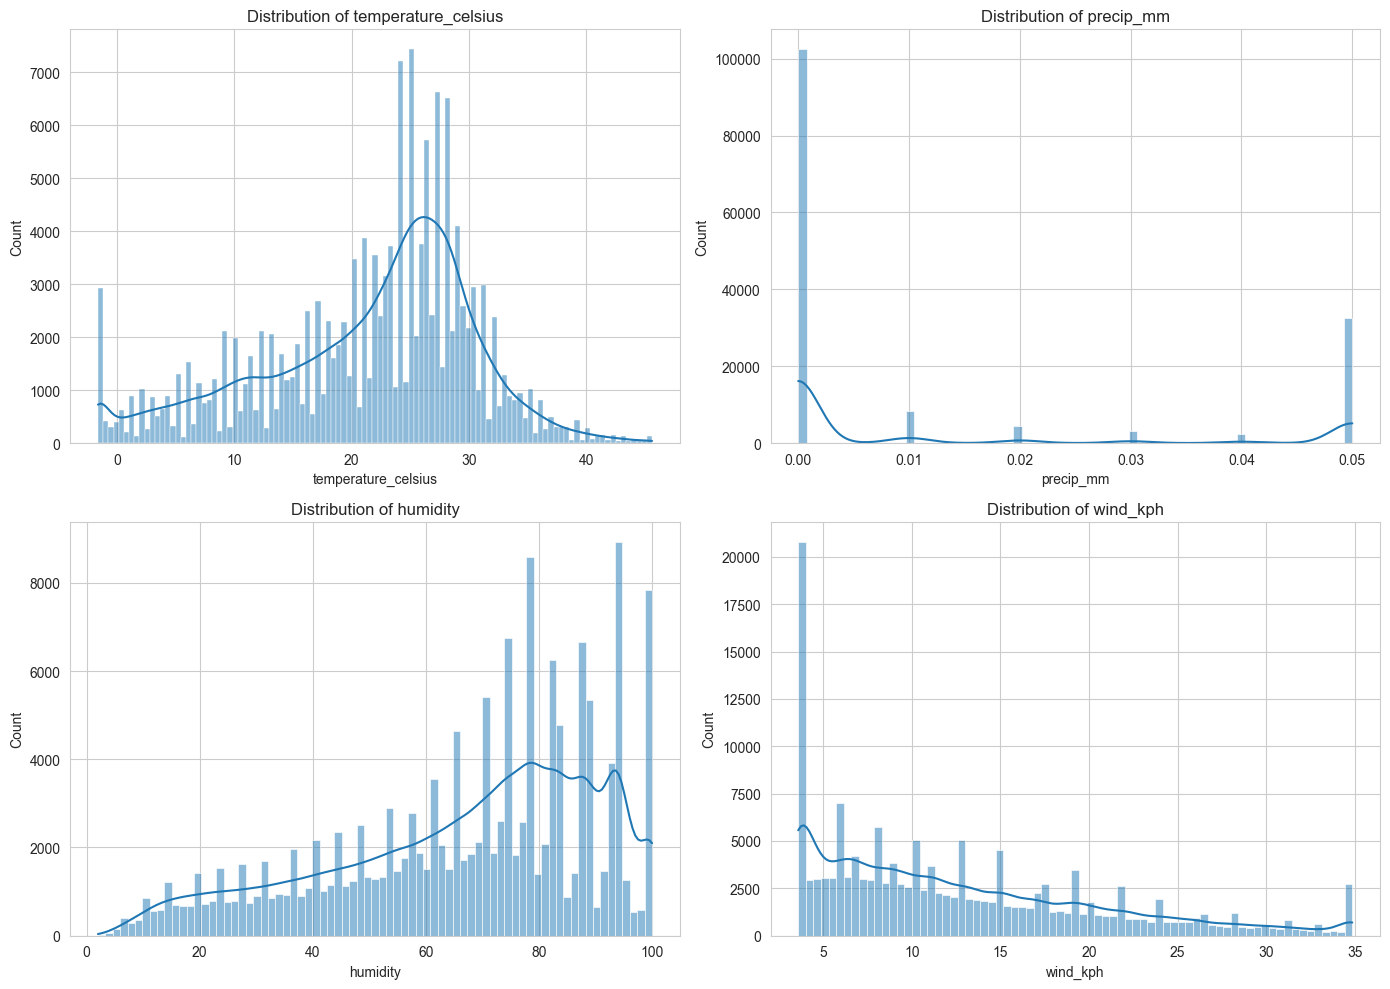

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_cols[:4]):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

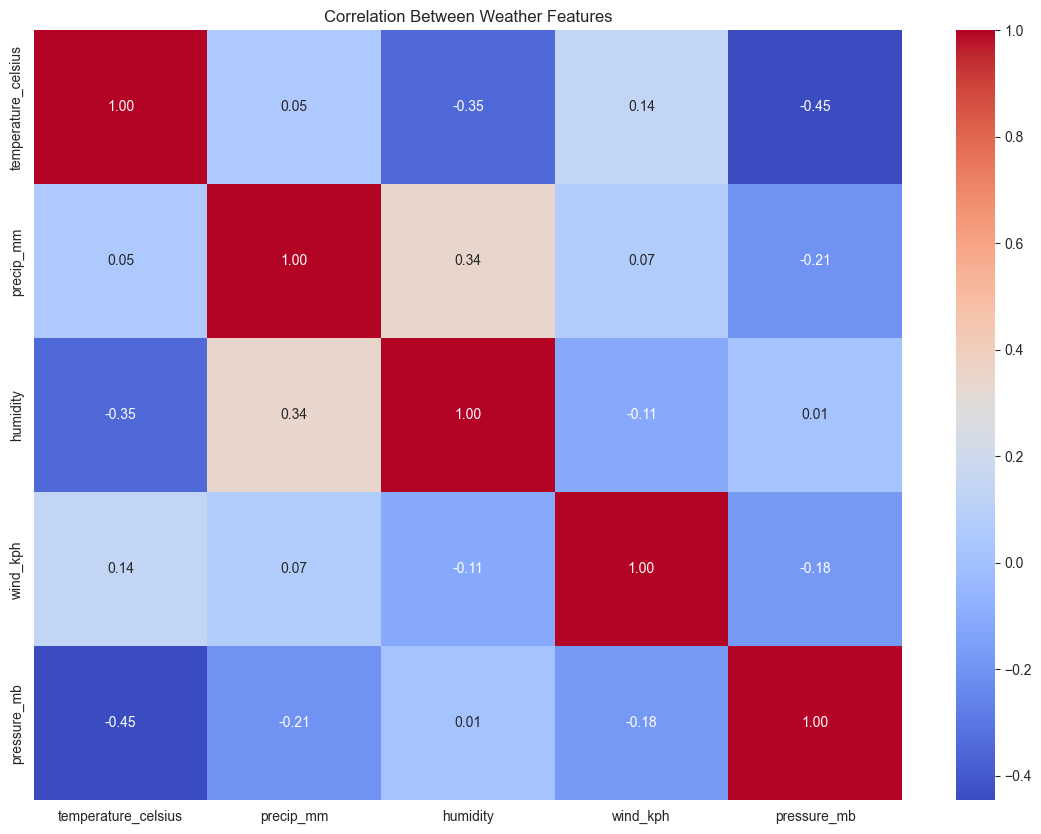

In [54]:
plt.figure(figsize=(14, 10))
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Weather Features')
plt.show()

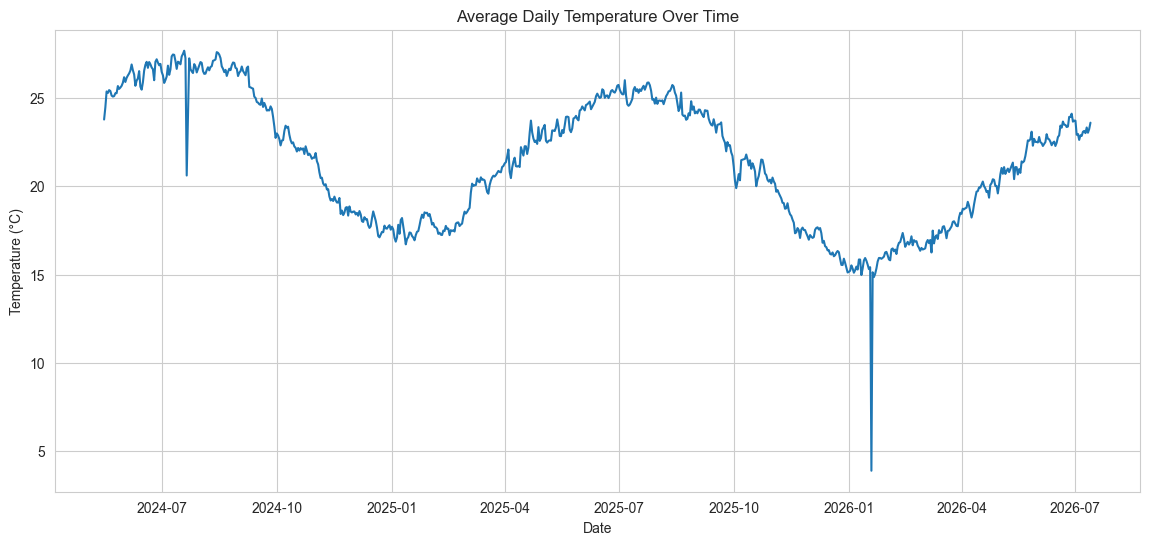

In [55]:
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()

plt.figure(figsize=(14, 6))
daily_temp.plot()
plt.title('Average Daily Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

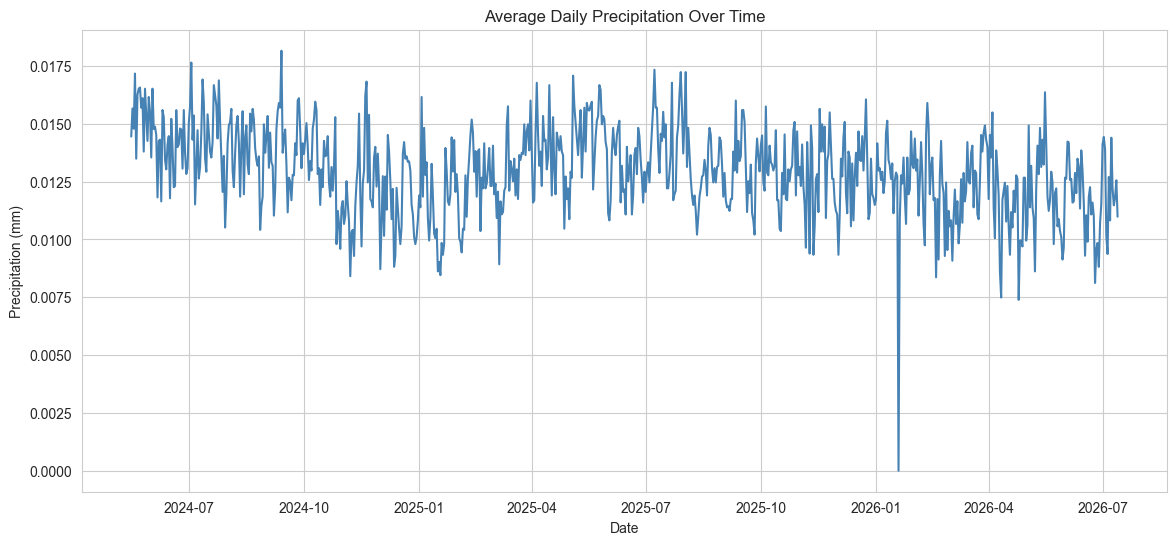

In [56]:
daily_precip = df.groupby(df['last_updated'].dt.date)['precip_mm'].mean()

plt.figure(figsize=(14, 6))
daily_precip.plot(color='steelblue')
plt.title('Average Daily Precipitation Over Time')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.show()

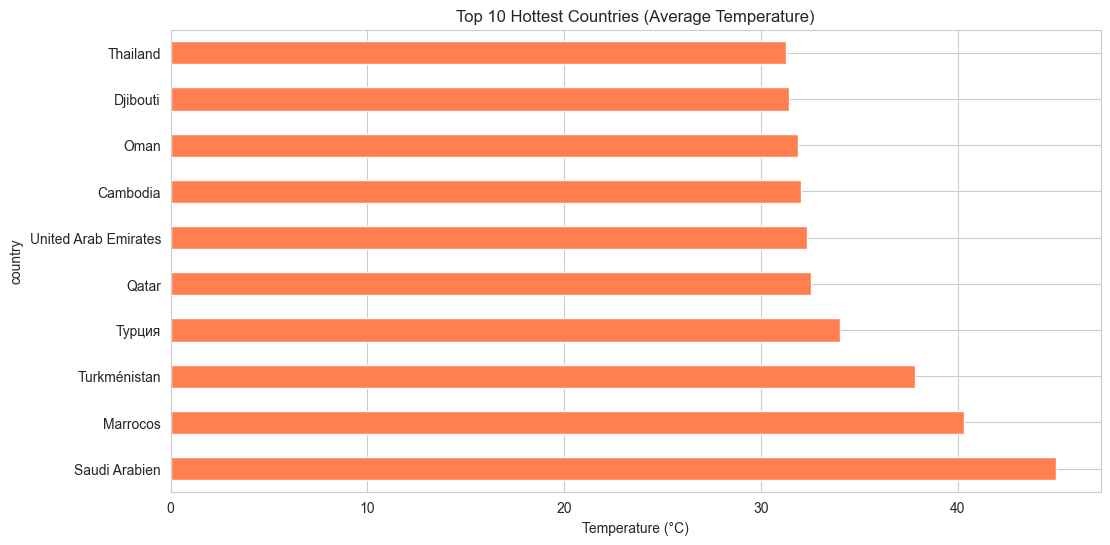

In [57]:
top_countries = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='barh', color='coral')
plt.title('Top 10 Hottest Countries (Average Temperature)')
plt.xlabel('Temperature (°C)')
plt.show()

In [58]:
ts = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
ts.index = pd.to_datetime(ts.index)
# fill any gap days
ts = ts.asfreq('D').interpolate()  

print(ts.head())
print("Length:", len(ts))

last_updated
2024-05-16    23.767196
2024-05-17    24.451648
2024-05-18    25.355610
2024-05-19    25.270103
2024-05-20    25.430769
Freq: D, Name: temperature_celsius, dtype: float64
Length: 789


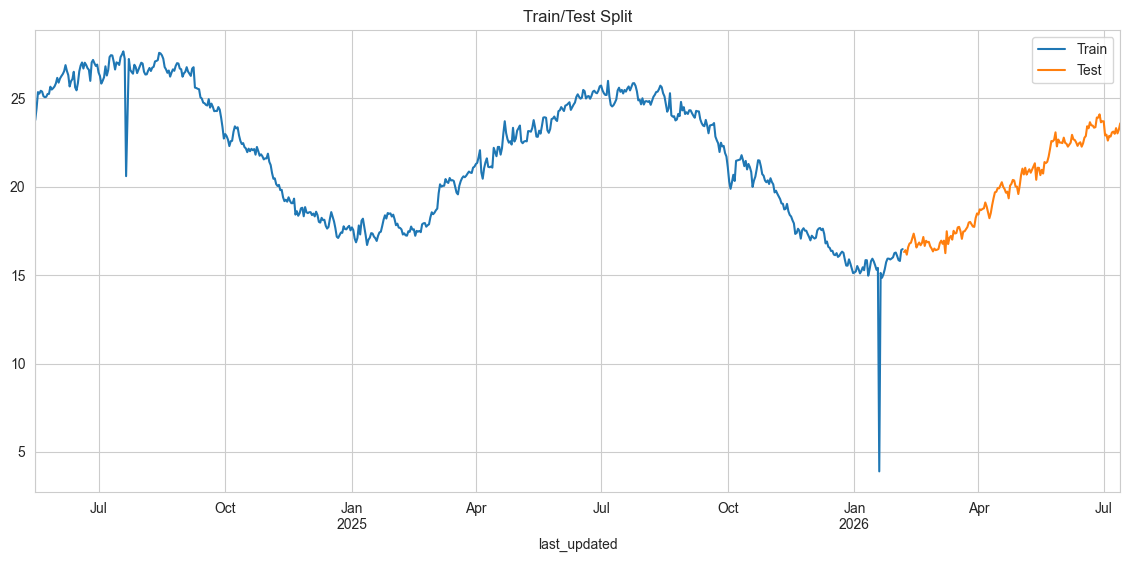

In [59]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

plt.figure(figsize=(14, 6))
train.plot(label='Train')
test.plot(label='Test')
plt.legend()
plt.title('Train/Test Split')
plt.show()

In [60]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     temperature_celsius   No. Observations:                  631
Model:                  ARIMA(2, 1, 2)   Log Likelihood                -664.794
Date:                 Mon, 13 Jul 2026   AIC                           1339.589
Time:                         23:39:41   BIC                           1361.817
Sample:                     05-16-2024   HQIC                          1348.223
                          - 02-05-2026                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2415     15.955     -0.015      0.988     -31.513      31.030
ar.L2          0.0590      2.507      0.024      0.981      -4.856       4.974
ma.L1         -0.2760     15.955     -0.017 

c:\Users\spectre\weather-trend-forecasting\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\spectre\weather-trend-forecasting\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MAE:  3.753
RMSE: 4.505
MAPE: 17.47%


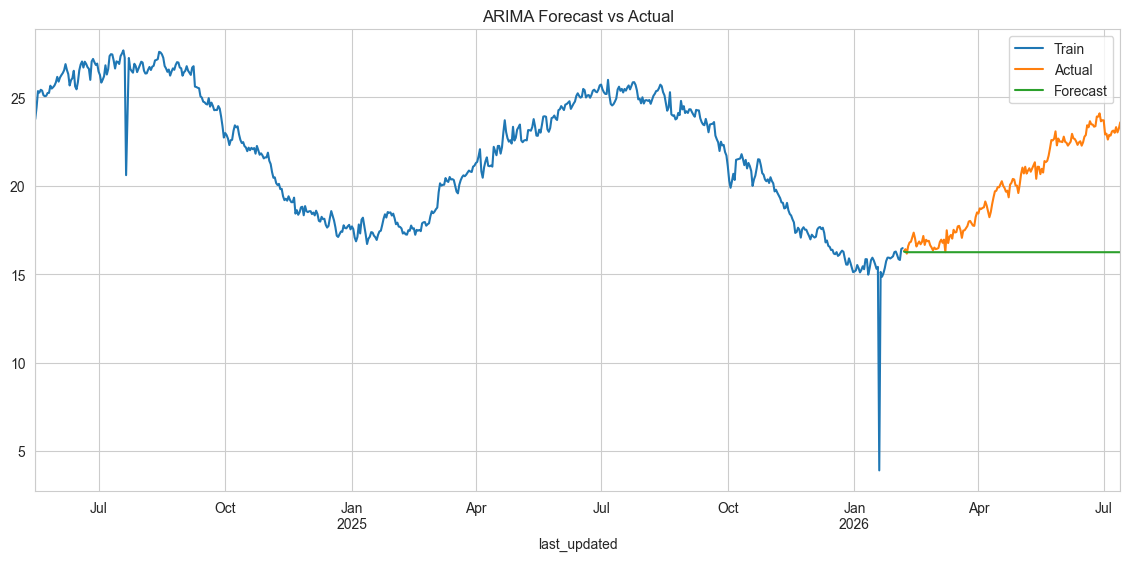

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(14, 6))
train.plot(label='Train')
test.plot(label='Actual')
forecast.plot(label='Forecast')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()